Feature Preparation for ANN

In [14]:
import numpy as np
import joblib

# Load X_train, X_test, y_train, y_test
X_train = joblib.load('/content/X_train.joblib')
X_test = joblib.load('/content/X_test.joblib')
y_train = joblib.load('/content/y_train.joblib')
y_test = joblib.load('/content/y_test.joblib')

# Convert boolean columns to integer (0 or 1)
X_train_ann = X_train.astype(int)
X_test_ann = X_test.astype(int)

print("X_train_ann shape after boolean to int conversion:", X_train_ann.shape)
print("X_test_ann shape after boolean to int conversion:", X_test_ann.shape)
print("First 5 rows of X_train_ann:")
print(X_train_ann.head())

X_train_ann shape after boolean to int conversion: (241, 22)
X_test_ann shape after boolean to int conversion: (61, 22)
First 5 rows of X_train_ann:
     age  trestbps  chol  thalach  oldpeak  sex_1  cp_1  cp_2  cp_3  fbs_1  \
158    1         0     3        0        0      0     0     1     0      0   
199    0         0     0       -1        0      1     0     0     0      0   
479    0         0     0        0        0      1     0     0     0      0   
460    1         0     0        0        0      1     0     1     0      0   
169   -1        -1    -1        0        0      0     1     0     0      0   

     ...  exang_1  slope_1  slope_2  ca_1  ca_2  ca_3  ca_4  thal_1  thal_2  \
158  ...        0        1        0     0     0     0     0       0       0   
199  ...        1        1        0     0     0     0     0       0       0   
479  ...        1        1        0     0     0     1     0       0       0   
460  ...        0        1        0     0     0     1     0       

In [16]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

# Define the ANN model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)), # Input layer + first hidden layer
    Dropout(0.3), # Dropout for regularization
    Dense(64, activation='relu'), # Second hidden layer
    Dropout(0.3), # Dropout for regularization
    Dense(32, activation='relu'), # Third hidden layer
    Dropout(0.2), # Dropout for regularization
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()
print(tf.__version__)
print(keras.__version__)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

2.20.0
3.13.2


raining the ANN Model with Early Stopping

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.5573 - loss: 0.6883 - val_accuracy: 0.7959 - val_loss: 0.6423
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6510 - loss: 0.6562 - val_accuracy: 0.7959 - val_loss: 0.6177
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6927 - loss: 0.6271 - val_accuracy: 0.7959 - val_loss: 0.5867
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7865 - loss: 0.5969 - val_accuracy: 0.7959 - val_loss: 0.5467
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7448 - loss: 0.5708 - val_accuracy: 0.7959 - val_loss: 0.5090
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7552 - loss: 0.5307 - val_accuracy: 0.8163 - val_loss: 0.4756
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8125 - loss: 0.4789 - val_accuracy: 0.8163 - val_loss: 0.4353
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8177 - loss: 0.4297 - val_accuracy: 0.7959 - val_loss:

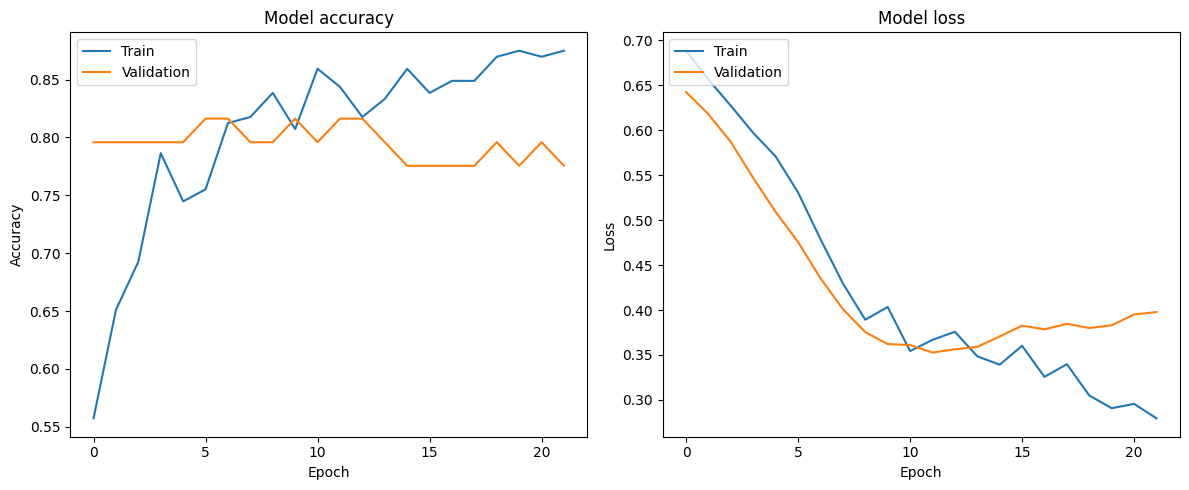

In [17]:
import matplotlib.pyplot as plt

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train_ann, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
from keras.models import load_model

# Load the pre-trained ANN model
loaded_model = load_model('/content/heart_disease_ann_model.keras')

# Display the loaded model summary
print("Loaded ANN Model Summary:")
loaded_model.summary()

Loaded ANN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,628 (104.02 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,315 (52.02 KB)

Evaluating the ANN Model and Comparison

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
--- Artificial Neural Network (ANN) Evaluation ---
Accuracy: 0.8525

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.93      0.85        28
           1       0.93      0.79      0.85        33

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61


Confusion Matrix:
[[26  2]
 [ 7 26]]


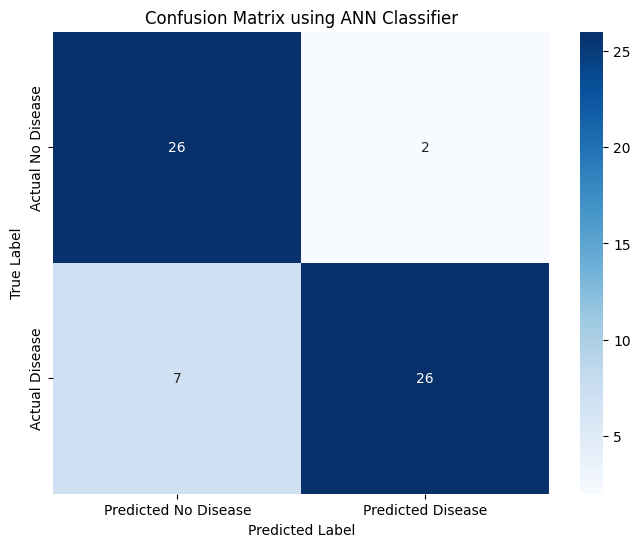

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_ann_proba = model.predict(X_test_ann)
y_pred_ann = (y_pred_ann_proba > 0.5).astype(int)

# Evaluate the ANN model
print("--- Artificial Neural Network (ANN) Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ann):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

# Get the confusion matrix for the tuned ANN model
cm_ann = confusion_matrix(y_test, y_pred_ann)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'])
plt.title('Confusion Matrix using ANN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')